# 02 -- Regional pairwise FST and implied migrants

Converts region-level Fst to implied number of migrants (Nm = (1-Fst) / 4*Fst).  
Visualizes implied migrants vs geographic distance.

**Input**
- `table_S1.tsv` —-> STAGdb metadata for samples included in manuscript (mostly to get coords)
- `table_2_fst.tsv` --> region-level pairwise Fst

**Output**
- `migrants_distance_matrix.tsv` --> Table S2

---

## Imports and paths

In [32]:
from __future__ import annotations

import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform

sys.path.insert(0, str(Path("../scripts")))
from gt_io import load_cache_npz
import popgen_utils

In [16]:
PROJECT_DIR = Path("/Users/kidelu001/awi-work/science/projects/apal_popgen/github")

# input
META_TSV = PROJECT_DIR / "table_S1.tsv"
FST_TSV  = PROJECT_DIR / "table_2_fst.tsv"

# output


In [19]:
fst = pd.read_csv(FST_TSV, sep="\t", low_memory=False, index_col=0)
fst

,Bahamas,Belize,Colombia,Colombia_SanAndres,Cuba,Curacao,Dominican Republic,Florida,Honduras,Jamaica,Mexico,Mexico_Gulf,Puerto Rico,USVI
Bahamas,NaN,"[0.085,\n0.097]","[0.082,\n0.095]","[0.026,\n0.037]","[0.018,\n0.023]","[0.056,\n0.064]","[0.021,\n0.025]","[0.043,\n0.05]","[0.083,\n0.095]","[0.029,\n0.034]","[0.055,\n0.067]","[0.073,\n0.081]","[0.035,\n0.04]","[0.045,\n0.055]"
Belize,0.091,NaN,"[0.085,\n0.094]","[0.069,\n0.082]","[0.074,\n0.085]","[0.105,\n0.117]","[0.094,\n0.106]","[0.017,\n0.02]","[0.001,\n0.002]","[0.093,\n0.103]","[0.04,\n0.052]","[0.002,\n0.003]","[0.105,\n0.117]","[0.116,\n0.133]"
Colombia,0.088,0.09,NaN,"[0.035,\n0.046]","[0.079,\n0.093]","[0.085,\n0.095]","[0.085,\n0.096]","[0.064,\n0.071]","[0.086,\n0.095]","[0.077,\n0.09]","[0.076,\n0.094]","[0.08,\n0.089]","[0.096,\n0.108]","[0.111,\n0.127]"
Colombia_SanAndres,0.033,0.075,0.04,NaN,"[0.023,\n0.036]","[0.051,\n0.063]","[0.037,\n0.049]","[0.028,\n0.038]","[0.069,\n0.083]","[0.032,\n0.045]","[0.039,\n0.057]","[0.056,\n0.07]","[0.044,\n0.056]","[0.061,\n0.076]"
Cuba,0.020,0.081,0.087,0.03,NaN,"[0.065,\n0.075]","[0.038,\n0.047]","[0.028,\n0.034]","[0.073,\n0.085]","[0.029,\n0.037]","[0.045,\n0.056]","[0.062,\n0.071]","[0.049,\n0.058]","[0.06,\n0.075]"
Curacao,0.060,0.111,0.09,0.056,0.069,NaN,"[0.055,\n0.062]","[0.071,\n0.079]","[0.107,\n0.118]","[0.07,\n0.078]","[0.075,\n0.09]","[0.099,\n0.109]","[0.043,\n0.05]","[0.055,\n0.065]"
Dominican Republic,0.023,0.1,0.091,0.043,0.042,0.058,NaN,"[0.055,\n0.063]","[0.093,\n0.106]","[0.037,\n0.045]","[0.068,\n0.083]","[0.083,\n0.093]","[0.03,\n0.035]","[0.045,\n0.055]"
Florida,0.046,0.019,0.068,0.032,0.031,0.075,0.059,NaN,"[0.017,\n0.021]","[0.049,\n0.055]","[0.017,\n0.026]","[0.013,\n0.016]","[0.065,\n0.073]","[0.075,\n0.089]"
Honduras,0.089,0.001,0.091,0.075,0.08,0.113,0.099,0.019,NaN,"[0.093,\n0.104]","[0.038,\n0.051]","[0.002,\n0.004]","[0.104,\n0.118]","[0.116,\n0.131]"
Jamaica,0.031,0.097,0.084,0.039,0.033,0.074,0.041,0.052,0.099,NaN,"[0.075,\n0.089]","[0.081,\n0.091]","[0.051,\n0.06]","[0.066,\n0.078]"


In [20]:
regions = fst.index.tolist()

fst_mat = pd.DataFrame(np.nan, index=regions, columns=regions, dtype=float)
ci_mat = pd.DataFrame("", index=regions, columns=regions, dtype="string")

for i, r1 in enumerate(regions):
    for j, r2 in enumerate(regions):
        val = fst.loc[r1, r2]

        if i == j:
            fst_mat.loc[r1, r2] = 0.0
            ci_mat.loc[r1, r2] = ""
        elif i > j:
            # lower triangle: FST values
            fst_mat.loc[r1, r2] = pd.to_numeric(val, errors="coerce")
            fst_mat.loc[r2, r1] = pd.to_numeric(val, errors="coerce")
        elif i < j:
            # upper triangle: CI strings
            ci_mat.loc[r1, r2] = "" if pd.isna(val) else str(val).replace("\n", " ")

#### Convert to implied migrants

In [21]:
n_mig_mat = pd.DataFrame(np.nan, index=fst_mat.index, columns=fst_mat.columns, dtype=float)

for r1 in fst_mat.index:
    for r2 in fst_mat.columns:
        fst = fst_mat.loc[r1, r2]

        if r1 == r2:
            n_mig_mat.loc[r1, r2] = np.nan
        elif pd.notna(fst) and (fst > 0) and (fst < 1):
            n_mig_mat.loc[r1, r2] = (1 - fst) / (4 * fst)

n_mig_mat

,Bahamas,Belize,Colombia,Colombia_SanAndres,Cuba,Curacao,Dominican Republic,Florida,Honduras,Jamaica,Mexico,Mexico_Gulf,Puerto Rico,USVI
Bahamas,NaN,2.497253,2.590909,7.325758,12.250000,3.916667,10.619565,5.184783,2.558989,7.814516,3.848361,2.996753,6.506757,4.750000
Belize,2.497253,NaN,2.527778,3.083333,2.836420,2.002252,2.250000,12.907895,249.750000,2.327320,5.305556,83.083333,2.002252,1.750000
Colombia,2.590909,2.527778,NaN,6.000000,2.623563,2.527778,2.497253,3.426471,2.497253,2.726190,2.726190,2.691176,2.200980,1.833333
Colombia_SanAndres,7.325758,3.083333,6.000000,NaN,8.083333,4.214286,5.563953,7.562500,3.083333,6.160256,4.958333,3.782258,4.651961,3.373188
Cuba,12.250000,2.836420,2.623563,8.083333,NaN,3.373188,5.702381,7.814516,2.875000,7.325758,4.651961,3.481343,4.466981,3.481343
Curacao,3.916667,2.002252,2.527778,4.214286,3.373188,NaN,4.060345,3.083333,1.962389,3.128378,2.762048,2.153846,5.069149,3.848361
Dominican Republic,10.619565,2.250000,2.497253,5.563953,5.702381,4.060345,NaN,3.987288,2.275253,5.847561,3.083333,2.590909,7.562500,4.651961
Florida,5.184783,12.907895,3.426471,7.562500,7.814516,3.083333,3.987288,NaN,12.907895,4.557692,11.654762,17.607143,3.373188,2.798780
Honduras,2.558989,249.750000,2.497253,3.083333,2.875000,1.962389,2.275253,12.907895,NaN,2.275253,5.431818,83.083333,1.982143,1.766129
Jamaica,7.814516,2.327320,2.726190,6.160256,7.325758,3.128378,5.847561,4.557692,2.275253,NaN,2.798780,2.656977,4.295455,3.222222


In [22]:
# save tsv
outdir = PROJECT_DIR
outdir.mkdir(exist_ok=True)

tsv_path = outdir / "n_migrants_region_matrix.tsv"
n_mig_mat.to_csv(tsv_path, sep="\t", index=False)

# print(f"Saved: {tsv_path.resolve()}")

### Load metadata

In [23]:
meta = pd.read_csv(META_TSV, sep="\t", low_memory=False)
meta.head()

,affymetrix_id,species,mlg,region,region_sub,region_fix_reason,reef,lat_old,lon_old,lat_clean,...,sample_id,user_specimen_id,perc_missing_data,perc_heterozygous,perc_acer,perc_apal,seq_facility,organization,Unnamed: 23,collection_date
0,121170171_(Axiom_AcropSNP)_K05.CEL,A.palmata,HG1491,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.703,22.17337,...,A12725,9334,0.17,0.63,0.54,98.80,Eurofins,Penn State,NaN,1/13/08
1,121170195_(Axiom_AcropSNP)_O05.CEL,A.palmata,HG1495,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.703,22.17337,...,A12749,9345,0.20,0.64,0.67,98.63,Eurofins,Penn State,NaN,1/13/08
2,121170183_(Axiom_AcropSNP)_M05.CEL,A.palmata,HG1498,Bahamas,Bahamas,NaN,AdelaineCay,22.17337,-75.703,22.17337,...,A12737,9335,0.20,1.03,0.40,98.51,Eurofins,Penn State,NaN,1/13/08
3,121166503_(Axiom_AcropSNP)_A05.CEL,A.palmata,HG1544,Bahamas,Bahamas,NaN,BlackBouy,23.80219,-76.146,23.80219,...,A12761,1643,0.21,0.56,0.36,99.01,Eurofins,Penn State,NaN,2/3/03
4,121166539_(Axiom_AcropSNP)_G05.CEL,A.palmata,HG1550,Bahamas,Bahamas,NaN,BlackBouy,23.80219,-76.146,23.80219,...,A12797,1658,0.21,0.34,0.41,99.18,Eurofins,Penn State,NaN,2/3/03


In [24]:
ID_COL        = "affymetrix_id"
MLG_COL       = "mlg"
REGION_COL    = "region"
SUBREGION_COL = "region_sub"
LAT_COL       = "lat_clean"
LON_COL       = "lon_clean"

#### Get region centroid coordinates

In [29]:
region_coords = (
    meta.groupby("region_sub", dropna=False)
    .agg(lat=(LAT_COL, "median"), lon=(LON_COL, "median"))
    .reset_index()
    .rename(columns={"region_sub": "region_sub"})
)

region_coords

,region_sub,lat,lon
0,Bahamas,24.063090,-76.373750
1,Belize,16.465654,-88.199008
2,Colombia,9.814720,-75.851100
3,Colombia_SanAndres,14.362500,-80.161400
4,Cuba,23.173200,-82.099300
5,Curacao,12.083100,-68.895600
6,Dominican Republic,18.401240,-68.846600
7,Florida,25.092770,-80.436139
8,Honduras,16.300000,-86.520000
9,Jamaica,18.522780,-77.764400


#### Compute geographic distance matrix

In [30]:
geo_mat = pd.DataFrame(np.nan, index=fst_mat.index, columns=fst_mat.columns, dtype=float)
coord_lookup = region_coords.set_index("region_sub")

for r1 in fst_mat.index:
    for r2 in fst_mat.columns:
        if r1 == r2:
            geo_mat.loc[r1, r2] = 0.0
        else:
            geo_mat.loc[r1, r2] = haversine_km(
                coord_lookup.loc[r1, "lat"], coord_lookup.loc[r1, "lon"],
                coord_lookup.loc[r2, "lat"], coord_lookup.loc[r2, "lon"],
            )

geo_mat

,Bahamas,Belize,Colombia,Colombia_SanAndres,Cuba,Curacao,Dominican Republic,Florida,Honduras,Jamaica,Mexico,Mexico_Gulf,Puerto Rico,USVI
Bahamas,0.000000,1493.807403,1585.315132,1149.413023,591.609184,1548.009203,1002.089235,426.424465,1365.189019,632.659128,1147.156553,1372.153525,1198.017249,1396.864386
Belize,1493.807403,0.000000,1527.090312,892.661958,981.193630,2135.311250,2063.288139,1252.865479,180.061098,1129.792090,495.246029,686.696839,2270.416465,2498.087997
Colombia,1585.315132,1527.090312,0.000000,689.365283,1627.148684,800.066010,1216.911808,1766.571829,1361.510334,989.970704,1700.798575,2039.258322,1324.733889,1492.433442
Colombia_SanAndres,1149.413023,892.661958,689.365283,0.000000,1000.668957,1245.356097,1287.463790,1193.496666,715.046025,528.500111,1011.503943,1350.702906,1473.962869,1692.820968
Cuba,591.609184,981.193630,1627.148684,1000.668957,0.000000,1862.736122,1475.461438,272.100380,893.201035,685.665916,567.607518,782.772307,1687.773979,1905.745564
Curacao,1548.009203,2135.311250,800.066010,1245.356097,1862.736122,0.000000,702.564757,1887.602172,1956.003070,1190.054371,2151.170653,2488.623622,686.843571,776.396139
Dominican Republic,1002.089235,2063.288139,1216.911808,1287.463790,1475.461438,702.564757,0.000000,1408.300484,1889.470113,940.580988,1913.571435,2217.536728,215.123948,441.968684
Florida,426.424465,1252.865479,1766.571829,1193.496666,272.100380,1887.602172,1408.300484,0.000000,1164.144531,780.804514,822.671910,986.223043,1611.539133,1816.821861
Honduras,1365.189019,180.061098,1361.510334,715.046025,893.201035,1956.003070,1889.470113,1164.144531,0.000000,961.136262,497.933798,763.484101,2095.283199,2322.563621
Jamaica,632.659128,1129.792090,989.970704,528.500111,685.665916,1190.054371,940.580988,780.804514,961.136262,0.000000,993.399237,1318.057852,1152.366948,1380.840272


#### Order regions by clustering on Fst

In [37]:
cluster_mat = fst_mat.copy()
np.fill_diagonal(cluster_mat.values, 0.0)
Z     = linkage(squareform(cluster_mat.to_numpy(), checks=False), method="average")
order = leaves_list(Z)
ordered_regions = fst_mat.index[order].tolist()

In [39]:
# re-order matrices

fst_mat_ord = fst_mat.loc[ordered_regions, ordered_regions]
geo_mat_ord = geo_mat.loc[ordered_regions, ordered_regions]
n_mig_mat_ord = n_mig_mat.loc[ordered_regions, ordered_regions]

#### Generate ordered matrix of implied migrants and geographic distance

In [69]:
mig_dist = pd.DataFrame("", index=ordered_regions, columns=ordered_regions, dtype="string")
for i, r1 in enumerate(ordered_regions):
    for j, r2 in enumerate(ordered_regions):
        if i < j:
            v = n_mig_mat_ord.loc[r1, r2]
            mig_dist.loc[r1, r2] = "" if pd.isna(v) else f"{v:.0f}"
        elif i > j:
            v = geo_mat_ord.loc[r1, r2]
            mig_dist.loc[r1, r2] = "" if pd.isna(v) else f"{v:.0f}"
        else:
            mig_dist.loc[r1, r2] = "—"

DISPLAY_RENAME = {
    "Colombia_SanAndres": "Col_SA",
    "Dominican Republic": "DR",
    "Mexico_Gulf":        "Mex_Gulf",
    "Puerto Rico":        "PR",
}

mig_dist_display = mig_dist.rename(index=DISPLAY_RENAME, columns=DISPLAY_RENAME)
mig_dist_display


,Colombia,Mexico,Florida,Mex_Gulf,Belize,Honduras,Curacao,PR,USVI,DR,Jamaica,Col_SA,Bahamas,Cuba
Colombia,—,3,3,3,3,2,3,2,2,2,3,6,3,3
Mexico,1701,—,12,7,5,5,3,3,2,3,3,5,4,5
Florida,1767,823,—,18,13,13,3,3,3,4,5,8,5,8
Mex_Gulf,2039,343,986,—,83,83,2,2,2,3,3,4,3,3
Belize,1527,495,1253,687,—,250,2,2,2,2,2,3,2,3
Honduras,1362,498,1164,763,180,—,2,2,2,2,2,3,3,3
Curacao,800,2151,1888,2489,2135,1956,—,5,4,4,3,4,4,3
PR,1325,2129,1612,2433,2270,2095,687,—,10,8,4,5,7,4
USVI,1492,2355,1817,2657,2498,2323,776,228,—,5,3,3,5,3
DR,1217,1914,1408,2218,2063,1889,703,215,442,—,6,6,11,6


In [72]:
# save tsv
outdir = PROJECT_DIR
outdir.mkdir(exist_ok=True)

tsv_path = outdir / "migrants_distance_matrix.tsv"
mig_dist.to_csv(tsv_path, sep="\t", index=False)

# print(f"Saved: {tsv_path.resolve()}")

# This is Table S2

----
### Plot

In [60]:
REGION_GROUP_MAP = {
    "Florida":            "Northern",
    "Bahamas":            "Northern",
    "Mexico":             "MesoAm",
    "Belize":             "MesoAm",
    "Honduras":           "MesoAm",
    "Cuba":               "GreaterAntilles",
    "Jamaica":            "GreaterAntilles",
    "Dominican Republic": "GreaterAntilles",
    "Puerto Rico":        "GreaterAntilles",
    "USVI":               "GreaterAntilles",
    "Curacao":            "Southern",
    "Colombia":           "Southern",
    "Colombia_SanAndres": "Colombia_SanAndres",
    "Mexico_Gulf":        "Mexico_Gulf",
}

REGION_GROUP_COLORS = {
    "Northern": "darkorange", 
    "GreaterAntilles": "cornflowerblue",
    "Southern": "yellowgreen",
    "MesoAm": "darkorchid",
    "Mex_Gulf": "indianred",
    "Colombia_SA": "forestgreen",
    "Cross-basin": "grey",
}



In [61]:
pairs = fst_mat_to_nm_long(
    fst_mat=fst_mat,
    region_coords=region_coords, 
    region_col="region_sub",
    lat_col="lat",
    lon_col="lon",
    pair_group_map=REGION_GROUP_MAP,
)

In [65]:
def fst_mat_to_nm_long(
    fst_mat,
    region_coords,
    region_col="region",
    lat_col="lat",
    lon_col="lon",
    pair_group_map=None,
):
    """
    Convert a symmetric FST matrix to a long table with:
    - fst
    - n_migrants
    - log10_n_migrants
    - geo_dist_km
    - optional pair_group
    """
    region_lookup = region_coords.set_index(region_col)
    rows = []

    for i, r1 in enumerate(fst_mat.index):
        for j, r2 in enumerate(fst_mat.columns):
            if i >= j:
                continue

            fst = fst_mat.loc[r1, r2]

            nm = np.nan
            log10_nm = np.nan
            if pd.notna(fst) and (fst > 0) and (fst < 1):
                nm = (1 - fst) / (4 * fst)
                if nm > 0:
                    log10_nm = np.log10(nm)

            geo_dist = haversine_km(
                region_lookup.loc[r1, lat_col],
                region_lookup.loc[r1, lon_col],
                region_lookup.loc[r2, lat_col],
                region_lookup.loc[r2, lon_col],
            )

            row = {
                "region1": r1,
                "region2": r2,
                "pair": f"{r1} – {r2}",
                "fst": fst,
                "n_migrants": nm,
                "log10_n_migrants": log10_nm,
                "geo_dist_km": geo_dist,
            }

            if pair_group_map is not None:
                g1 = pair_group_map.get(r1, "Other")
                g2 = pair_group_map.get(r2, "Other")
                row["group1"] = g1
                row["group2"] = g2
                row["pair_group"] = g1 if g1 == g2 else "Cross-basin"

            rows.append(row)

    return pd.DataFrame(rows)

In [67]:
def plot_nm_vs_distance(
    plot_df,
    y_col="log10_n_migrants",
    pair_group_colors=None,
    label_sd_mult=1.5,
    # label_top_n=5,
    label_side="both",
    label_offsets=None,
    default_label_style=None,
    point_size=80,
    point_edgecolor="black",
    point_linewidth=0.8,
    alpha=0.85,
    figsize=(7, 7),
    title=None,
    xlabel="Geographic distance (km)",
    ylabel=None,
    save_base=None,
):
    """
    Scatter plot of implied migrants vs distance with OLS fit and outlier labels.

    Outliers are defined as points whose residuals exceed label_sd_mult * SD(residuals).

    label_side:
      - "both"  -> label unusually high or low residuals
      - "above" -> label only points above the regression line
      - "below" -> label only points below the regression line

    label_offsets can be a dict keyed by row['pair'], with values like:
    {"Belize – Honduras": {"dx": 20, "dy": 0.03, "ha": "left", "va": "bottom"}}
    """
    if pair_group_colors is None:
        pair_group_colors = {"Cross-group": "#888888"}

    if label_offsets is None:
        label_offsets = {}

    if default_label_style is None:
        default_label_style = {"dx": 8, "dy": 0.0, "ha": "left", "va": "center"}

    df = plot_df.copy()
    valid = np.isfinite(df["geo_dist_km"]) & np.isfinite(df[y_col])
    df = df.loc[valid].copy()

    if df.empty:
        raise ValueError(f"No finite values found for y_col='{y_col}' and geo_dist_km.")

    ols = stats.linregress(df["geo_dist_km"], df[y_col])
    df["pred"] = ols.slope * df["geo_dist_km"] + ols.intercept
    df["resid"] = df[y_col] - df["pred"]
    df["abs_resid"] = df["resid"].abs()

    resid_sd = df["resid"].std()
    cutoff = label_sd_mult * resid_sd

    if label_side == "both":
        label_df = df.loc[df["abs_resid"] >= cutoff].copy()
    elif label_side == "above":
        label_df = df.loc[df["resid"] >= cutoff].copy()
    elif label_side == "below":
        label_df = df.loc[df["resid"] <= -cutoff].copy()
    else:
        raise ValueError("label_side must be one of: 'both', 'above', 'below'")

    fig, ax = plt.subplots(figsize=figsize)

    group_col = "pair_group" if "pair_group" in df.columns else None

    if group_col is not None:
        for group, subdf in df.groupby(group_col):
            ax.scatter(
                subdf["geo_dist_km"],
                subdf[y_col],
                label=group,
                alpha=alpha,
                s=point_size,
                c=pair_group_colors.get(group, "#888888"),
                edgecolors=point_edgecolor,
                linewidths=point_linewidth,
            )
    else:
        ax.scatter(
            df["geo_dist_km"],
            df[y_col],
            alpha=alpha,
            s=point_size,
            c="#888888",
            edgecolors=point_edgecolor,
            linewidths=point_linewidth,
        )

    xline = np.linspace(df["geo_dist_km"].min(), df["geo_dist_km"].max(), 200)
    ax.plot(
        xline,
        ols.slope * xline + ols.intercept,
        linewidth=1,
        color="grey",
    )
    # print(label_df) # more easily check which label placements need adjustment
    
    for _, row in label_df.iterrows():
        style = default_label_style.copy()
        style.update(label_offsets.get(row["pair"], {}))

        ax.text(
            row["geo_dist_km"] + style["dx"],
            row[y_col] + style["dy"],
            row["pair"],
            fontsize=8,
            alpha=0.9,
            ha=style["ha"],
            va=style["va"],
        )

    if ylabel is None:
        ylabel = "log10 implied Nm" if y_col == "log10_n_migrants" else "Implied Nm"

    if title is None:
        title = "Region-pair connectivity vs distance"

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    if group_col is not None:
        ax.legend(frameon=False)

    plt.tight_layout()

    if save_base is not None:
        save_base = str(save_base)
        fig.savefig(f"{save_base}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_base}.ps", format="ps", bbox_inches="tight")
        fig.savefig(f"{save_base}.eps", format="eps", bbox_inches="tight")

    plt.show()

    return {
        "plot_df": df,
        "label_df": label_df,
        "ols": ols,
        "r2": ols.rvalue ** 2,
        "resid_sd": resid_sd,
        "cutoff": cutoff,
    }

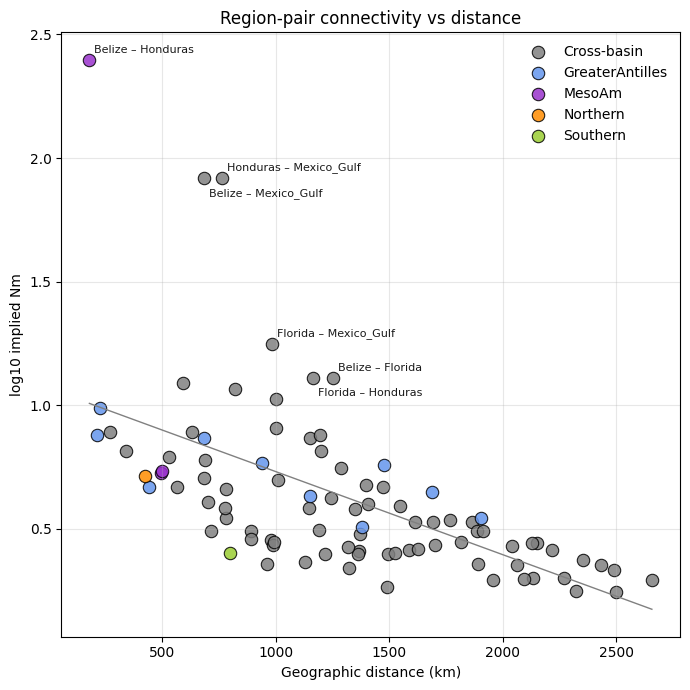

In [68]:
dx = 21
dy = 0.02
label_offsets_log = {
    "Belize – Honduras": {"dx": dx, "dy": dy, "ha": "left", "va": "bottom"},
    "Honduras – Mexico_Gulf": {"dx": dx, "dy": dy, "ha": "left", "va": "bottom"},
    "Belize – Mexico_Gulf": {"dx": dx, "dy": -0.04, "ha": "left", "va": "top"},
    "Florida – Mexico_Gulf": {"dx": dx, "dy": dy, "ha": "left", "va": "bottom"},
    "Belize – Florida": {"dx": dx, "dy": dy, "ha": "left", "va": "bottom"},
    "Florida – Honduras": {"dx": dx, "dy": -0.04, "ha": "left", "va": "top"},
    "Colombia – Curacao": {"dx": 20.5, "dy": -0.06, "ha": "left", "va": "top"},
}


res_log = plot_nm_vs_distance(
    pairs,
    y_col="log10_n_migrants",
    pair_group_colors=REGION_GROUP_COLORS,
    label_sd_mult=1.5,
    label_side="both",
    label_offsets=label_offsets_log,
    title="Region-pair connectivity vs distance",
    ylabel="log10 implied Nm",
    # save_base=PLOTS_DIR / "scatter_log10migrants_vs_distance_NL_outliers=SD1,5",
)